In [14]:
#analyzing SNOD dataset with a counterpropagation network
#the goal is to see if we can 
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#imports
import seaborn as sns

#sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, root_mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import StratifiedKFold, cross_val_score

import random


In [2]:
#upload the data
df = pd.read_csv('data/input_df_SUMMmet.csv')  

In [3]:
print(df.columns)
print(df.head())
print(len(df))

Index(['Unnamed: 0', 'date', 'site.x', 'SNOD', 'ant1d_SNOD', 'delta', 'day',
       'slope', 'aspect', 'tpi', 'pai_mean', 'pai_sd', 'rumple', 'height_max',
       'height_mean', 'height_95pct', 'canopy_relief_ratio', 'entropy',
       'pct_conifer', 'ndvi_total_mean', 'ndvi_con_mean',
       'vertical_gap_fraction', 'Elevation', 'X', 'mean_temp', 'max_temp',
       'min_temp', 'total_solar', 'pressure', 'rel_humidity', 'precip',
       'avg_wind_speed', 'max_wind_speed', 'ant3d_precip', 'ant1d_mean_temp',
       'ant1d_max_temp', 'ant1d_min_temp', 'site.y'],
      dtype='object')
   Unnamed: 0        date site.x     SNOD  ant1d_SNOD  delta  day      slope  \
0           1  2022-11-08   SUMM   9.5167         NaN    NaN  312  16.813133   
1           2  2022-11-09   SUMM   7.0167      9.5167   -2.5  313  16.813133   
2           3  2022-11-10   RB07   0.7405         NaN    NaN  314   8.955874   
3           4  2022-11-10   SUMM  11.5167      7.0167    4.5  314  16.813133   
4           5

In [4]:
#clean out rows with nan entries and columns that are completely nan
df = df.dropna(axis=1, how='all')
df = df.dropna()

#dropping irrelavant sites
sites_to_drop = ['PTSH', 'SPST', 'SR01', 'SR25', 'SR11']
df = df[~df['site.x'].isin(sites_to_drop)]

In [5]:
#split and setup features and target for model
#3-class target sourced from delta(change in snow depth day over day)
# 1 = increase, 2 = decrease, 3 = no change
threshold = 1e-6    #handles negligible changes in snow depth
y = pd.Series(3, index=df.index)    #default - no change
y[df['delta'] > threshold] = 1  #1 - increase
y[df['delta'] < -threshold] = 2 #2 - decrease
y = y.astype(int)

#now select numeric features and drop identifiers for features
df = df.drop(columns=['Unnamed: 0', 'date', 'site.x', 'site.y', 'SNOD', 'delta', 'X']) #just removes day of snow depth feature
# X = df.drop(columns=['Unnamed: 0', 'date', 'site.x', 'SNOD', 'ant1d_SNOD', 'delta']) #removes day befores snow depth value as well

#make df = X
X = df

In [6]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# instantiate and train MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(256,256,64), 
                    batch_size=16,
                    activation='relu',
                    solver='adam', learning_rate='adaptive',
                    learning_rate_init=.001,
                    max_iter=1000, early_stopping=True,
                    alpha=.00001,
                    validation_fraction=0.1,
                    n_iter_no_change=50,
                    random_state=42)
mlp.fit(X_train_scaled, y_train)

MLPClassifier(alpha=1e-05, batch_size=16, early_stopping=True,
              hidden_layer_sizes=(256, 256, 64), learning_rate='adaptive',
              max_iter=1000, n_iter_no_change=50, random_state=42)

In [8]:
# param_grid = {
#     'hidden_layer_sizes': [(200, 200, 25), (256, 256, 64), (200, 150, 100, 50)],
#     'n_iter_no_change': [10, 20, 50, 100],
#     'max_iter': [1000,3000,5000],
#     'alpha': [0.00001, 0.0001, 0.001],
#     'batch_size': [16, 32, 64],
#     'learning_rate_init': [0.0001, 0.001, 0.01]
# }

# mlp_base = MLPClassifier(solver='adam',
#                          activation='relu', early_stopping=True, random_state=42)
# grid = GridSearchCV(mlp_base, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
# grid.fit(X_train_scaled, y_train)

# print(f"Best params: {grid.best_params_}")
# print(f"Best CV accuracy: {grid.best_score_:.4f}")

In [8]:
# labels -> human readable names (matches 1,2,3)
target_labels = [1, 2, 3]
target_names = ['increase', 'decrease', 'no_change']

# predict and evaluate
y_pred = mlp.predict(X_test_scaled)
# metrics
rmse = root_mean_squared_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, labels=target_labels, target_names=target_names, digits=4)
cm = confusion_matrix(y_test, y_pred, labels=target_labels)

RMSE: 0.7599342076785331
R2 score: -0.25735241587883695

Accuracy: 0.6550
Classification report:
              precision    recall  f1-score   support

    increase     0.6523    0.6231    0.6374       268
    decrease     0.7102    0.8010    0.7529       407
   no_change     0.3647    0.2480    0.2952       125

    accuracy                         0.6550       800
   macro avg     0.5758    0.5574    0.5618       800
weighted avg     0.6369    0.6550    0.6427       800



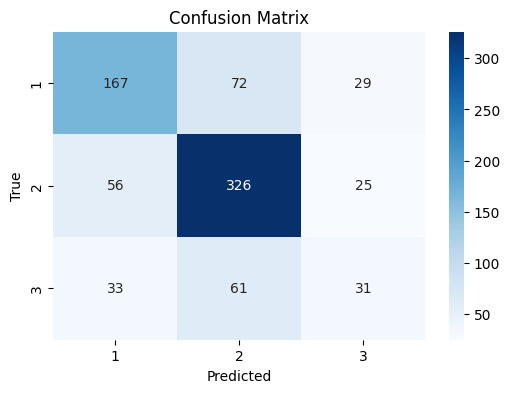

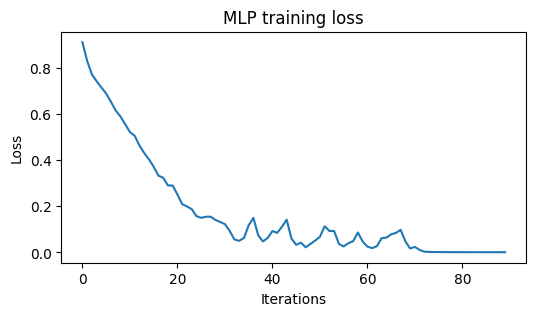

In [9]:
#RMSE and R2
print(f'RMSE: {rmse}')
print(f'R2 score: {r2_score}\n')

print(f'Accuracy: {acc:.4f}')
print('Classification report:')
print(report)

# plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# optional: training loss curve
plt.figure(figsize=(6,3))
plt.plot(mlp.loss_curve_)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('MLP training loss')
plt.show()

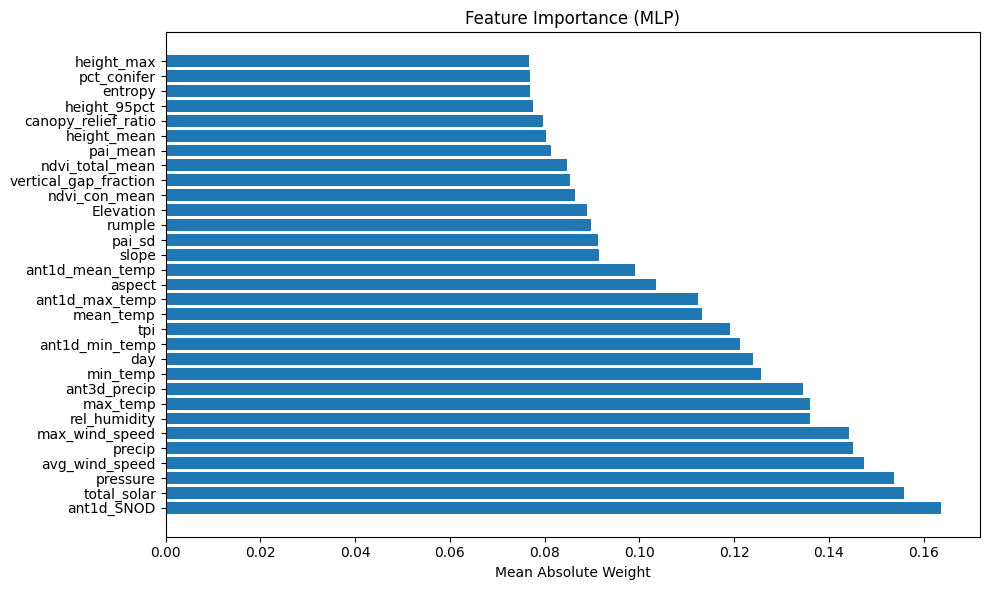

Top 10 Important Features:
1. ant1d_SNOD: 0.1637
2. total_solar: 0.1558
3. pressure: 0.1538
4. avg_wind_speed: 0.1474
5. precip: 0.1451
6. max_wind_speed: 0.1443
7. rel_humidity: 0.1360
8. max_temp: 0.1360
9. ant3d_precip: 0.1346
10. min_temp: 0.1257


In [10]:
# New cell: feature importance analysis
feature_importance = np.abs(mlp.coefs_[0]).mean(axis=1)
feature_names = X.columns

# sort by importance
sorted_idx = np.argsort(feature_importance)[::-1]

# plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Mean Absolute Weight')
plt.title('Feature Importance (MLP)')
plt.tight_layout()
plt.show()

# print top features
print('Top 10 Important Features:')
for i, idx in enumerate(sorted_idx[:10]):
    print(f'{i+1}. {feature_names[idx]}: {feature_importance[idx]:.4f}')

In [12]:
mlp2 = MLPClassifier(hidden_layer_sizes=(256,256,64), 
                    batch_size=16,
                    activation='relu',
                    solver='adam', learning_rate='adaptive',
                    learning_rate_init=.001,
                    max_iter=1000, early_stopping=True,
                    alpha=.00001,
                    validation_fraction=0.1,
                    n_iter_no_change=50,
                    random_state=42)

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_features = X.shape[1]

def evaluate_subset_on_train(feature_idx_list):
    X_sub = X_train.iloc[:, feature_idx_list]
    scores = cross_val_score(mlp2, X_sub, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    return scores.mean(), scores.std()

In [17]:
# 1) Test top-K subsets
topk_results = []
max_k = min(30, n_features)      # try up to 30 features or the full set
for k in range(1, max_k+1):
    idx = list(sorted_idx[:k])
    mean, std = evaluate_subset_on_train(idx)
    topk_results.append({'method':'topk', 'k':k, 'mean':mean, 'std':std, 'features':idx})

# # 2) Test random-K subsets (sample a few)
# random_results = []
# n_repeats = 10
# for k in range(1, min(15, n_features)+1):    # fewer repeats for large k
#     for rep in range(n_repeats):
#         idx = random.sample(list(range(n_features)), k)
#         mean, std = evaluate_subset_on_train(idx)
#         random_results.append({'method':'random', 'k':k, 'mean':mean, 'std':std, 'features':idx})

# # 3) Greedy forward selection (adds best remaining one-by-one)
# greedy_results = []
# selected = []
# remaining = list(sorted_idx)  # start candidates are importance-sorted (faster)
# best_so_far = 0
# for k in range(1, min(20, n_features)+1):
#     best = None
#     best_score = -1
#     for cand in remaining:
#         cand_list = selected + [cand]
#         mean, _ = evaluate_subset_on_train(cand_list)
#         if mean > best_score:
#             best_score = mean
#             best = cand
#     if best is None:
#         break
#     selected.append(best)
#     remaining.remove(best)
#     greedy_results.append({'method':'greedy', 'k':k, 'mean':best_score, 'features':selected.copy()})
#     if best_score > best_so_far:
#         best_so_far = best_score

In [18]:
# Consolidate results to DataFrame and find best
df_topk = pd.DataFrame(topk_results)
# df_random = pd.DataFrame(random_results)
# df_greedy = pd.DataFrame(greedy_results)
all_results = pd.concat([df_topk], ignore_index=True)

best_row = all_results.loc[all_results['mean'].idxmax()]
print("Best cross-val result on train set:")
print(best_row[['method','k','mean']])

Best cross-val result on train set:
method        topk
k                1
mean      0.577544
Name: 0, dtype: object


In [19]:
# Train final model on X_train with those features and evaluate on X_test
best_features = best_row['features']
X_train_best = X_train.iloc[:, best_features]
X_test_best = X_test.iloc[:, best_features]

mlp2.fit(X_train_best, y_train)
y_pred_test = mlp2.predict(X_test_best)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Test accuracy with best subset ({best_row['method']}, k={best_row['k']}): {test_acc:.4f}")
print("Classification report on test set:")
print(classification_report(y_test, y_pred_test, labels=target_labels, target_names=target_names, digits=4))


Test accuracy with best subset (topk, k=1): 0.5687
Classification report on test set:
              precision    recall  f1-score   support

    increase     0.8500    0.1269    0.2208       268
    decrease     0.5643    0.9705    0.7136       407
   no_change     0.4333    0.2080    0.2811       125

    accuracy                         0.5687       800
   macro avg     0.6159    0.4351    0.4052       800
weighted avg     0.6395    0.5687    0.4809       800



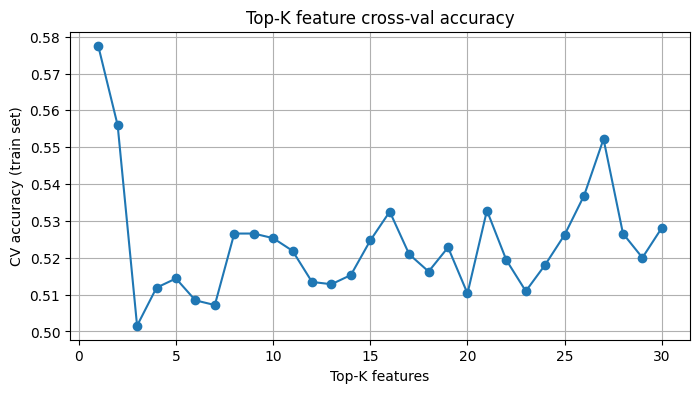

In [20]:
agg = df_topk.groupby('k')['mean'].mean().reset_index()
plt.figure(figsize=(8,4))
plt.plot(agg['k'], agg['mean'], marker='o')
plt.xlabel('Top-K features')
plt.ylabel('CV accuracy (train set)')
plt.title('Top-K feature cross-val accuracy')
plt.grid(True)
plt.show()

Cannot get SNOD classifier to improve higher than 65% accuracy
- do not know what else to do to improve it
- I tried grid search cv that ran for over to try and optimize params and this was the best I could do
- It just might not work very well